In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import MDAnalysis as mda
import pandas as pd

class MDConfig:
    def __init__(self, start_frame, end_frame, protein_atoms, directory_prefix, plots_directory, csv_directory, file_prefix):
        self.start_frame = start_frame
        self.end_frame = end_frame
        self.protein_atoms = protein_atoms
        self.directory_prefix = directory_prefix
        self.plots_directory = plots_directory
        self.csv_directory = csv_directory
        self.file_prefix = file_prefix
        self.x_limits = (0, 100)
        self.y_limits = (0, 100)
        
    def get_file_path(self, file_type, frame_idx):
        return os.path.join(self.directory_prefix, f"results{file_type}", f"{file_type}_frame_{frame_idx}.gro")
    
def check_and_create_directory(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)
        
def analyze_and_plot(u, config, label, color, subplot_index, leaflet='bottom', collect_data=False):
    box_dimensions = u.dimensions
    box_z_length = box_dimensions[2]
    midpoint_z = box_z_length / 2
    ag_protein_heavy = u.select_atoms(f"bynum 1:{config.protein_atoms} and not name H*")

    # Selecting leaflet atoms based on leaflet choice
    leaflet_atoms = u.select_atoms(f'resname O and prop z {"<" if leaflet == "bottom" else ">"} {midpoint_z}')

    close_protein_atoms_map = {}
    for protein_atom in ag_protein_heavy:
        for defect_atom in leaflet_atoms:
            distance_xy = np.linalg.norm(protein_atom.position[:2] - defect_atom.position[:2])
            z_distance = protein_atom.position[2] - defect_atom.position[2]
            if leaflet == 'bottom':
                is_directly_above_or_below = z_distance >= 2.0  # At least 2 angstroms above
            else:  # leaflet == 'top'
                is_directly_above_or_below = z_distance <= -2.0  # At least 2 angstroms below
            
            if distance_xy <= 1.5 and is_directly_above_or_below:
                close_protein_atoms_map[protein_atom.index] = (protein_atom.residue, label)
                break

#             distance_xy = np.linalg.norm(protein_atom.position[:2] - defect_atom.position[:2])
#             if leaflet == 'bottom':
#                 is_directly_above_or_below = protein_atom.position[2] > defect_atom.position[2] 
#             else:  # leaflet == 'top'
#                 is_directly_above_or_below = protein_atom.position[2] < defect_atom.position[2] 
            
#             if distance_xy <= 1.5 and is_directly_above_or_below:
#                 close_protein_atoms_map[protein_atom.index] = (protein_atom.residue, label)
#                 break

    leaflet_label = f'{label}'
    protein_label = 'Protein interactions'

    plt.subplot(1, 3, subplot_index)
    plt.scatter(leaflet_atoms.positions[:, 0], leaflet_atoms.positions[:, 1], color=color, label=leaflet_label)
    plt.scatter(ag_protein_heavy.positions[:, 0], ag_protein_heavy.positions[:, 1], color='red', alpha=0.5)
    
    if config.x_limits is not None:
        plt.xlim(config.x_limits)
    if config.y_limits is not None:
        plt.ylim(config.y_limits)

    # Plot interactions
    for atom_index in close_protein_atoms_map:
        atom = u.atoms[atom_index]
        plt.scatter(atom.position[0], atom.position[1], color='yellow', edgecolor='black', s=50, label=protein_label if atom_index == list(close_protein_atoms_map.keys())[0] else "")

    plt.legend(loc='upper right')
    plt.axis('square')

    return close_protein_atoms_map if collect_data else {}



# def analyze_and_plot(u, config, label, color, subplot_index, leaflet='bottom', collect_data=False):
#     box_dimensions = u.dimensions
#     box_z_length = box_dimensions[2]
#     midpoint_z = box_z_length / 2
#     ag_protein_heavy = u.select_atoms(f"bynum 1:{config.protein_atoms} and not name H*")

#     # Selecting leaflet atoms and calculating z boundaries
#     if leaflet == 'bottom':
#         leaflet_atoms = u.select_atoms(f'resname O and prop z < {midpoint_z}')
#         leaflet_z_max = np.max(leaflet_atoms.positions[:, 2])
#         leaflet_z_min = 0
#     else:
#         leaflet_atoms = u.select_atoms(f'resname O and prop z > {midpoint_z}')
#         leaflet_z_min = np.min(leaflet_atoms.positions[:, 2])
#         leaflet_z_max = box_z_length

#     relevant_protein_atoms = ag_protein_heavy[np.logical_and(ag_protein_heavy.positions[:, 2] > leaflet_z_min, ag_protein_heavy.positions[:, 2] < leaflet_z_max)]

#     close_protein_atoms_map = {}
#     for protein_atom in relevant_protein_atoms:
#         for defect_atom in leaflet_atoms:
#             distance_xy = np.linalg.norm(protein_atom.position[:2] - defect_atom.position[:2])
#             if distance_xy <= 1.5:
#                 close_protein_atoms_map[protein_atom.index] = (protein_atom.residue, label)
#                 break

#     leaflet_label = f'{label}'
#     protein_label = 'Protein interactions'

#     plt.subplot(1, 3, subplot_index)
#     plt.scatter(leaflet_atoms.positions[:, 0], leaflet_atoms.positions[:, 1], color=color, label=leaflet_label)
#     plt.scatter(ag_protein_heavy.positions[:, 0], ag_protein_heavy.positions[:, 1], color='red', alpha=0.5)
    
#     if config.x_limits is not None:
#         plt.xlim(config.x_limits)
#     if config.y_limits is not None:
#         plt.ylim(config.y_limits)

#     for atom_index in close_protein_atoms_map:
#         atom = u.atoms[atom_index]
#         plt.scatter(atom.position[0], atom.position[1], color='yellow', edgecolor='black', s=50, label=protein_label if atom_index == list(close_protein_atoms_map.keys())[0] else "")

#     plt.legend(loc='upper right')
#     plt.axis('square')

#     return close_protein_atoms_map if collect_data else {}

def plot_molecules_from_gro(config, frame_idx, leaflet='bottom'):
    plt.figure(figsize=(18, 6))
    u2 = mda.Universe(config.get_file_path('PLacyl', frame_idx)) if os.path.exists(config.get_file_path('PLacyl', frame_idx)) else None
    u3 = mda.Universe(config.get_file_path('TGacyl', frame_idx)) if os.path.exists(config.get_file_path('TGacyl', frame_idx)) else None
    u4 = mda.Universe(config.get_file_path('TGglyc', frame_idx)) if os.path.exists(config.get_file_path('TGglyc', frame_idx)) else None

    if not (u2 and u3 and u4):
        print(f"Files not found for frame {frame_idx}")
        return False

    analyze_and_plot(u2, config, 'PLacyl', 'blue', 1, leaflet)
    analyze_and_plot(u3, config, 'TGacyl', 'green', 2, leaflet)
    analyze_and_plot(u4, config, 'TGglyc', 'orange', 3, leaflet)

    plt.savefig(os.path.join(config.plots_directory, f'frame_{frame_idx}_{leaflet}.png'))
    plt.show()
    return True

def save_to_csv(data_map, config):
    data_list = []
    for (frame_idx, atom_idx), (residue, defect_type) in data_map.items():
        data_list.append({
            'Frame Index': frame_idx,
            'Atom Index': atom_idx,
            'Residue': residue,
            'Defect Type': defect_type
        })

Processing Frame: 319


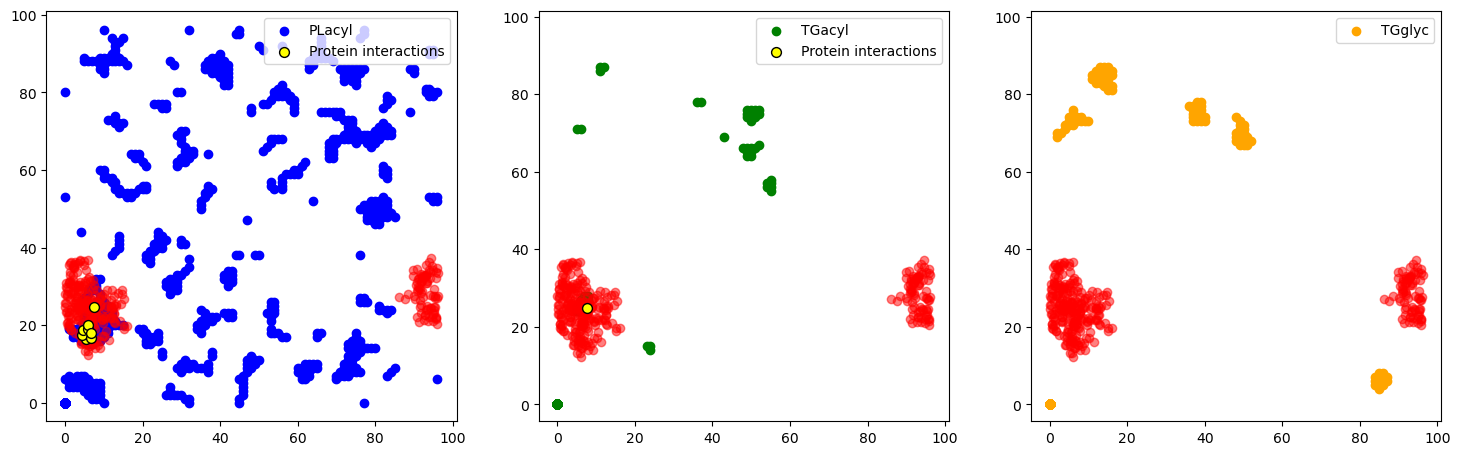

Processing Frame: 320


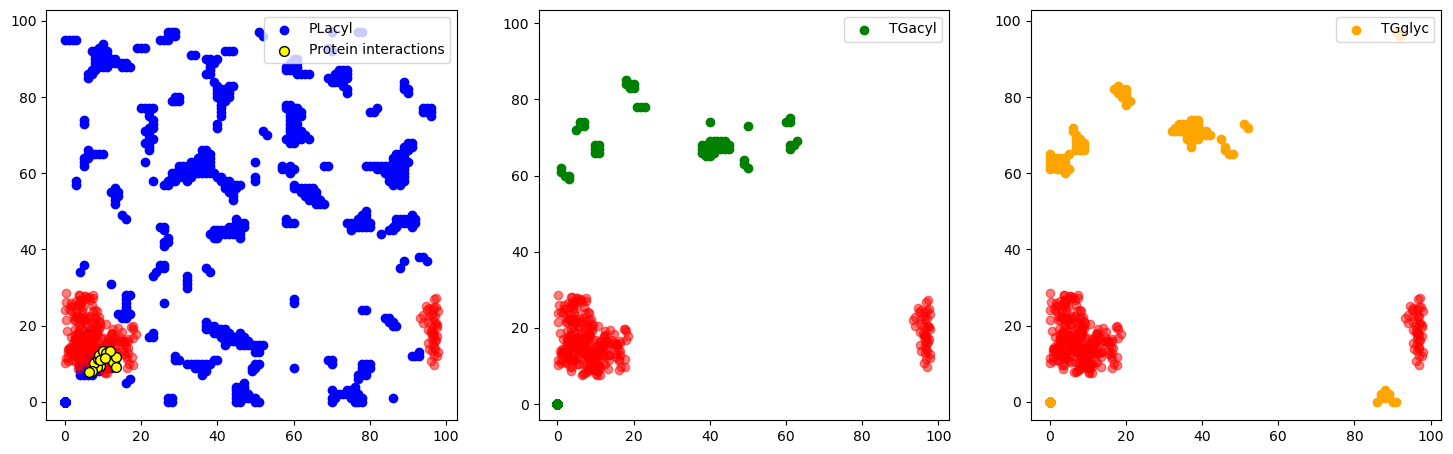

Processing Frame: 321


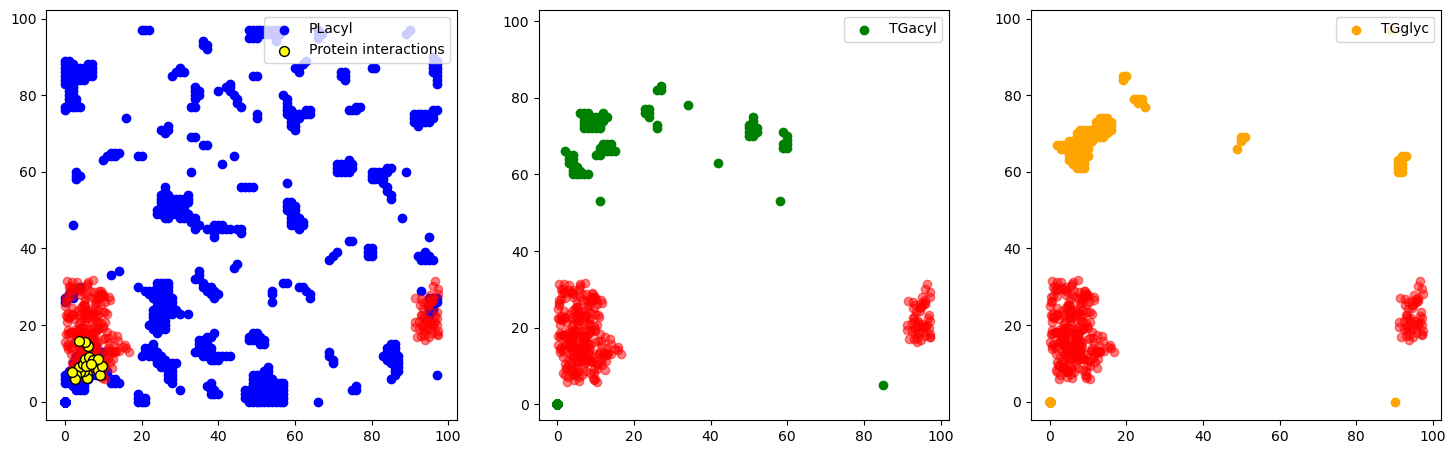

Processing Frame: 322


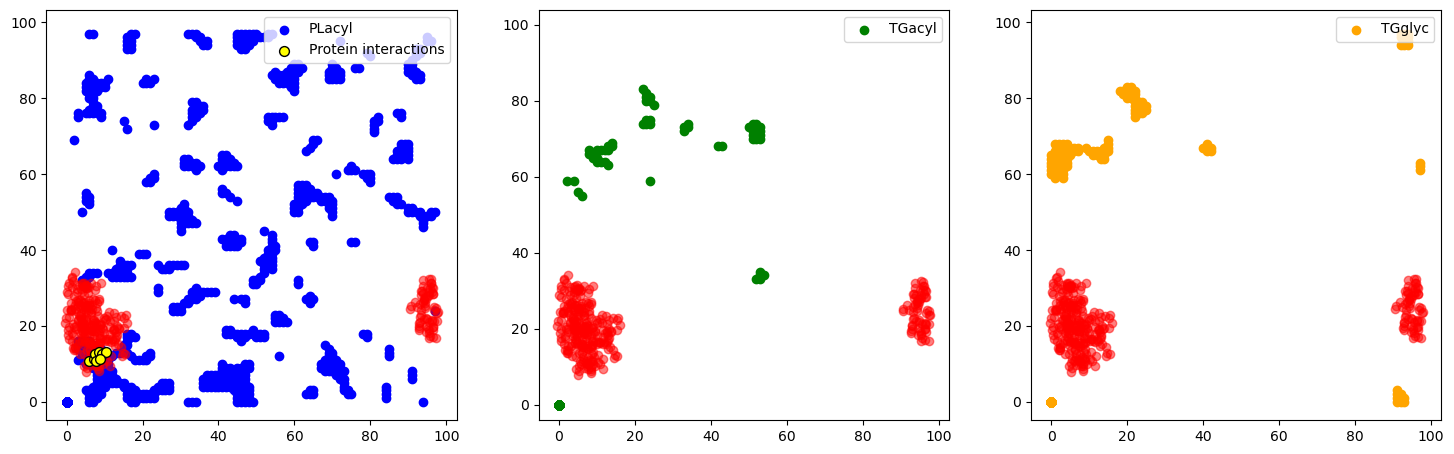

Processing Frame: 323


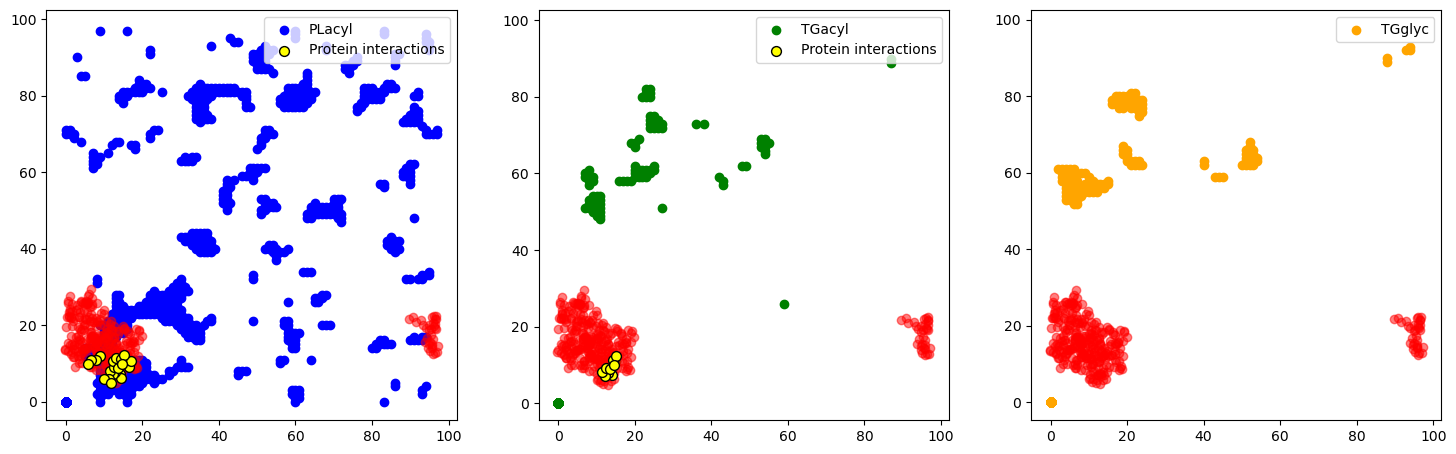

Processing Frame: 324


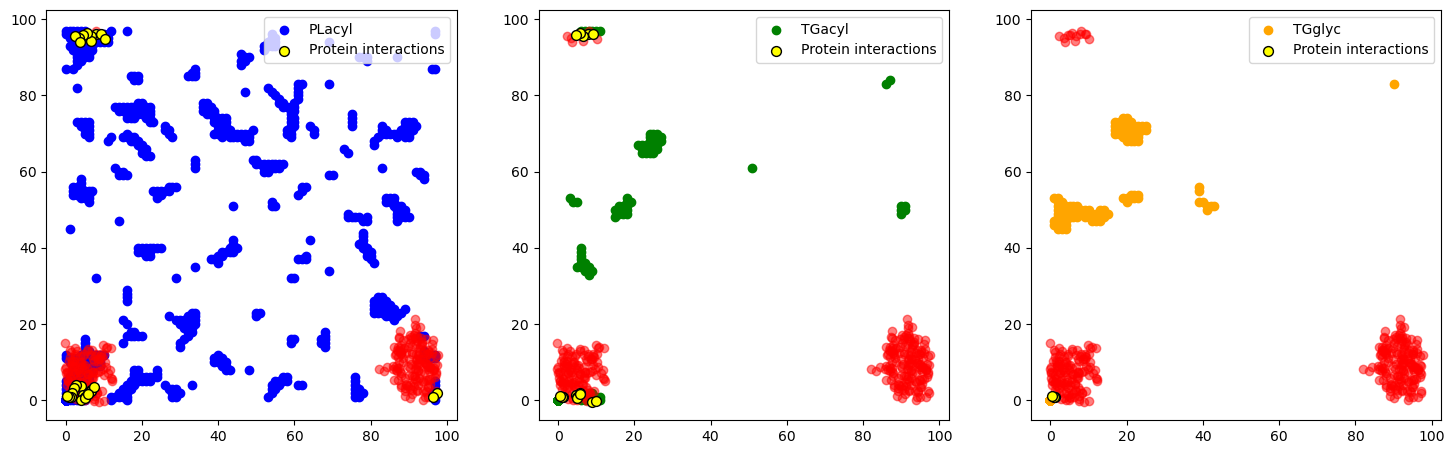

Processing Frame: 325


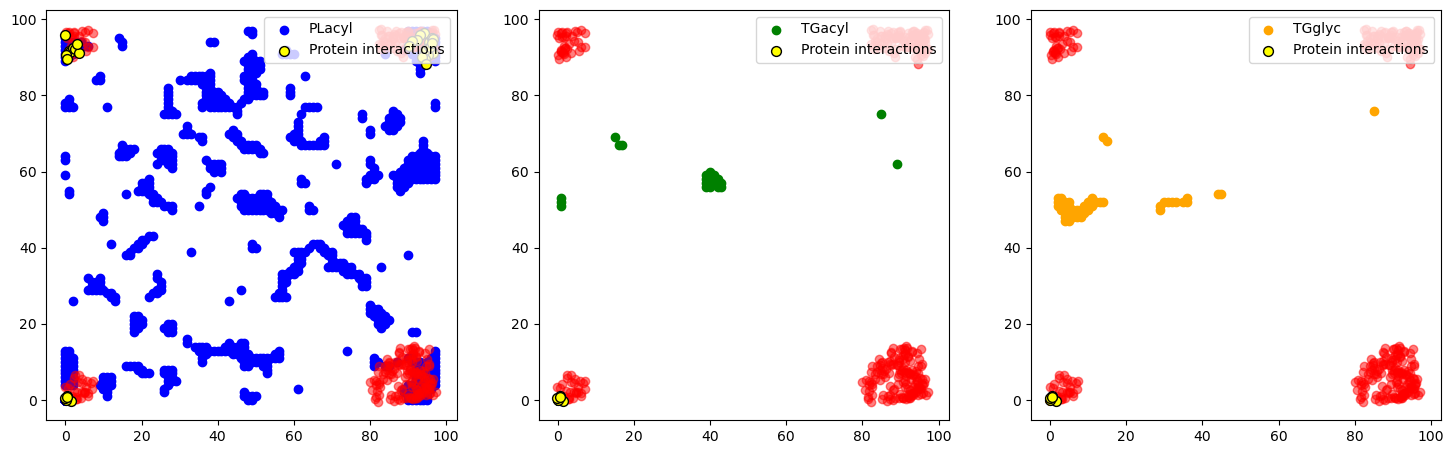

Processing Frame: 326


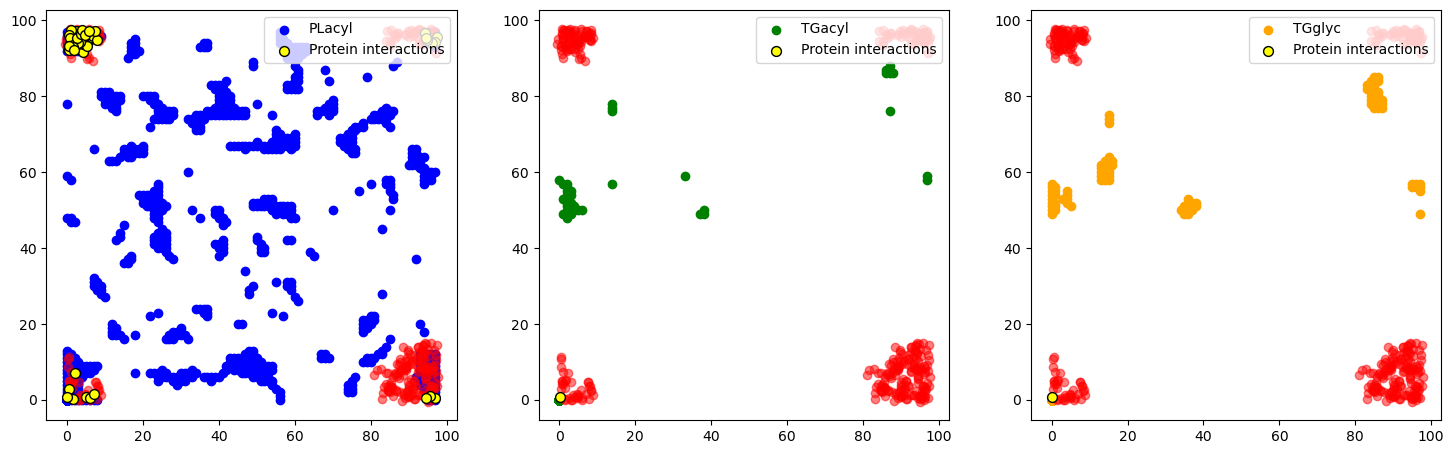

Processing Frame: 327


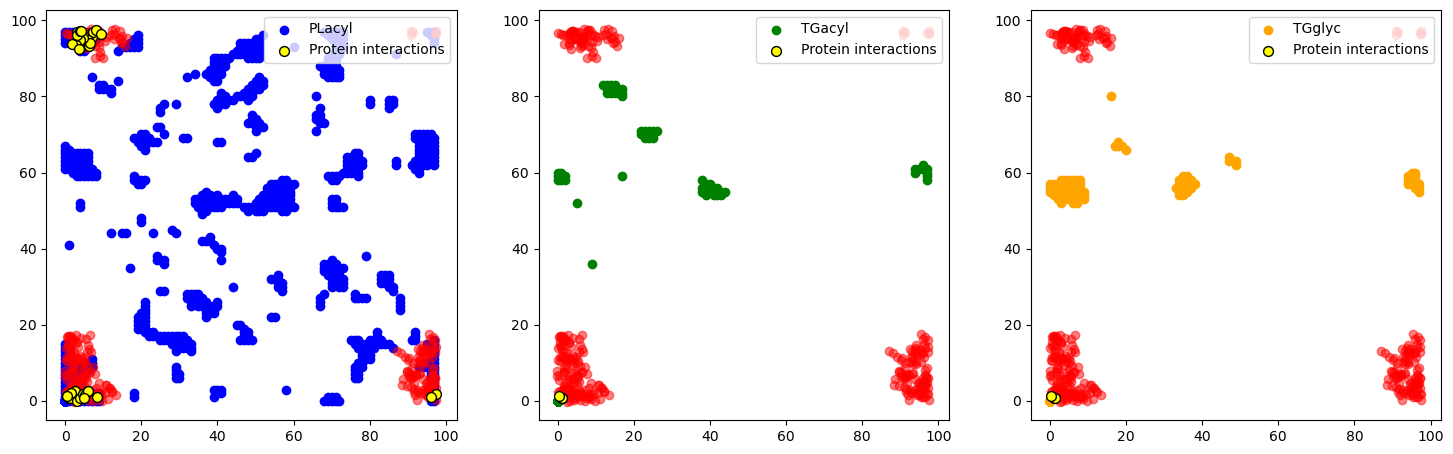

Processing Frame: 328


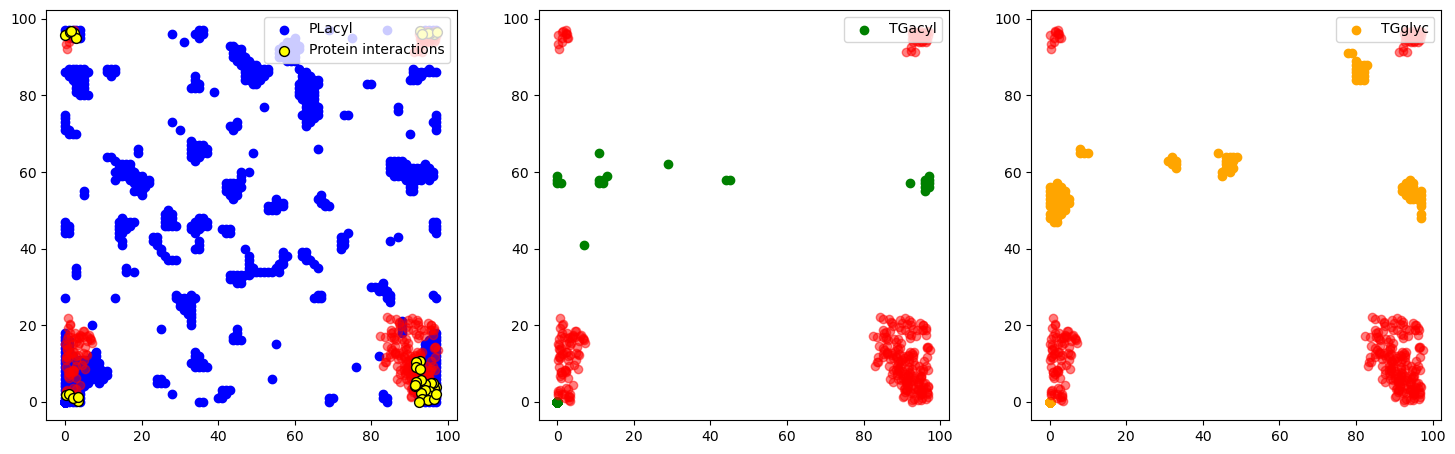

Processing Frame: 329


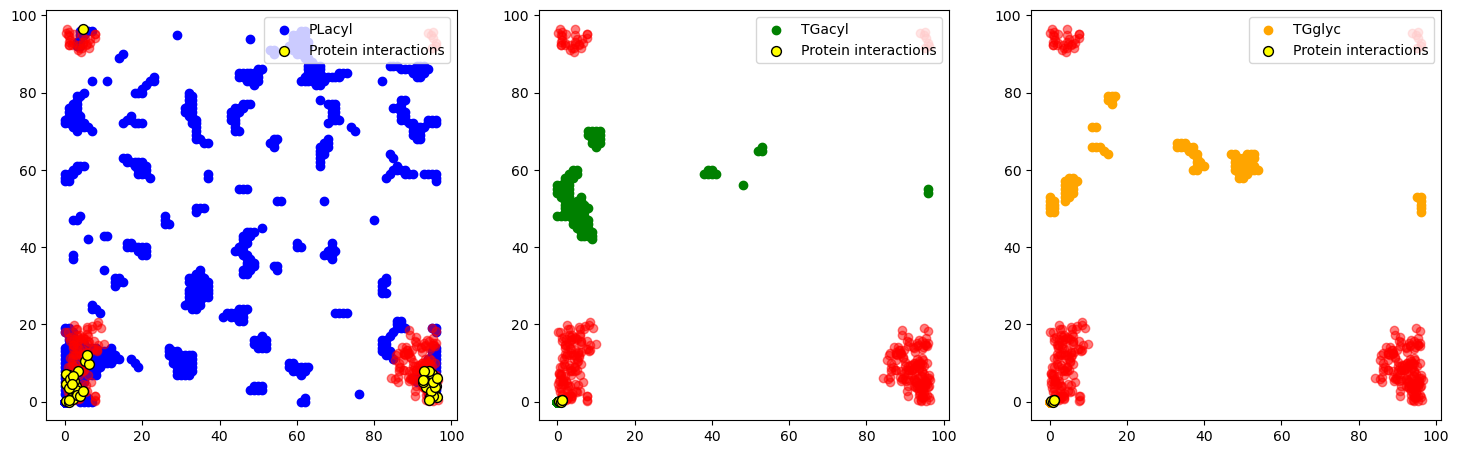

Processing Frame: 330


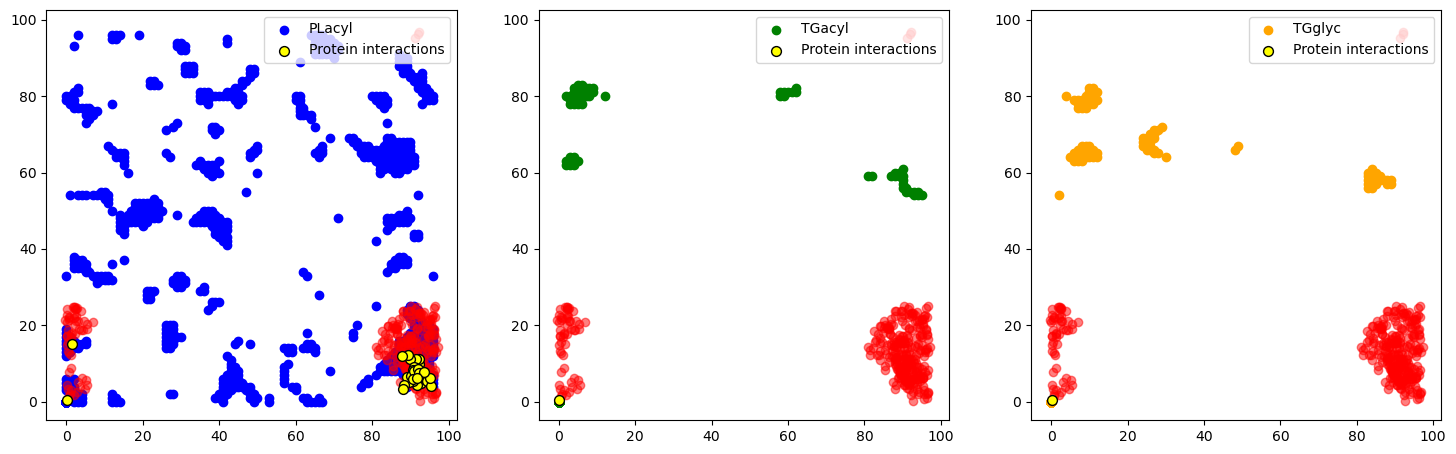

Processing Frame: 331


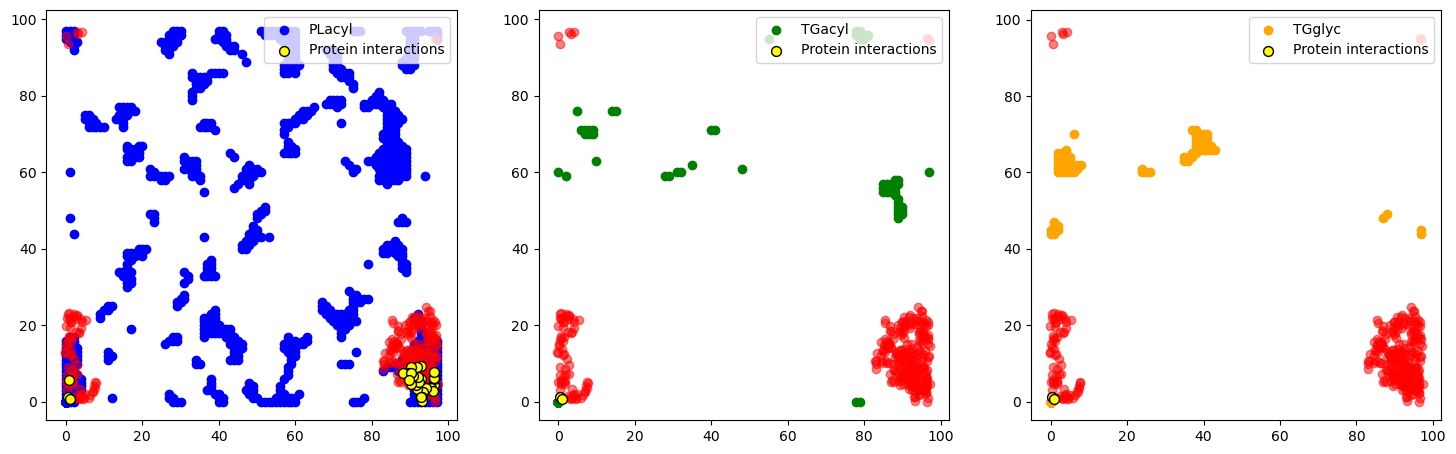

Processing Frame: 332


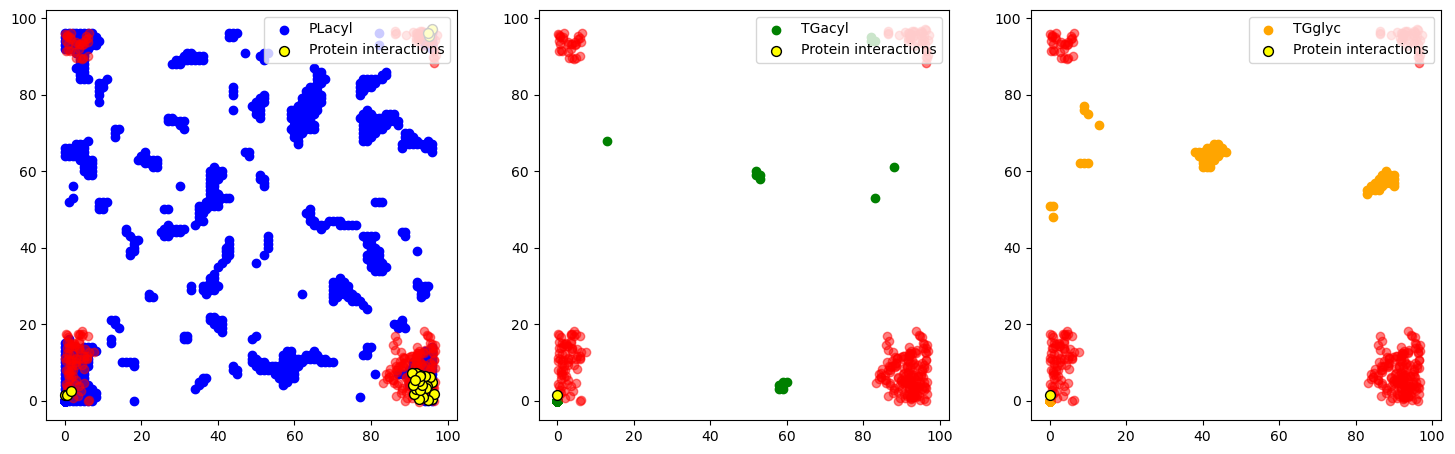

Processing Frame: 333


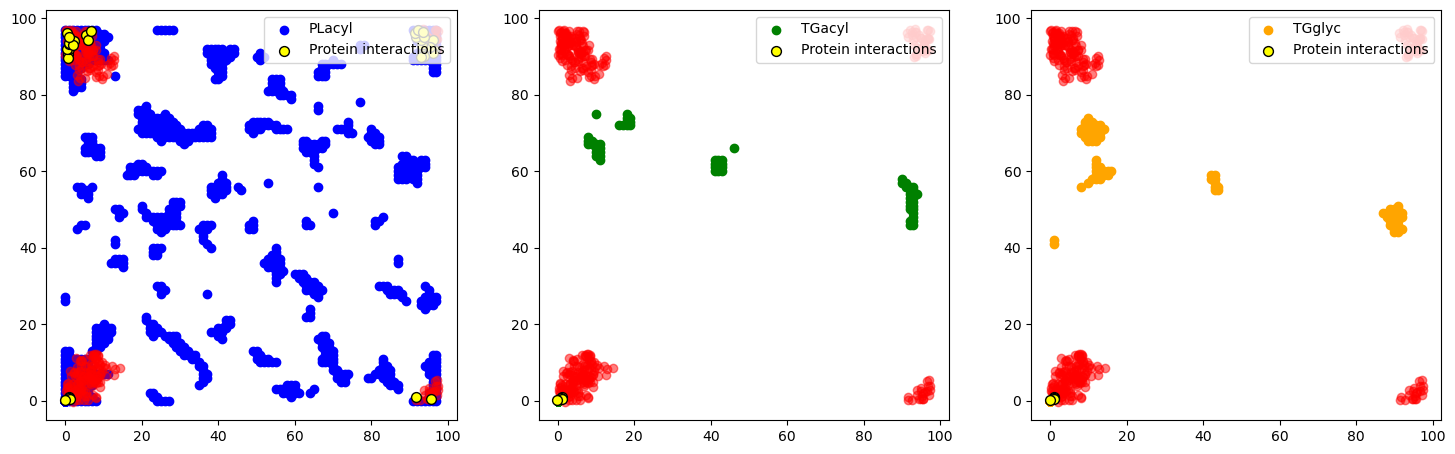

Processing Frame: 334


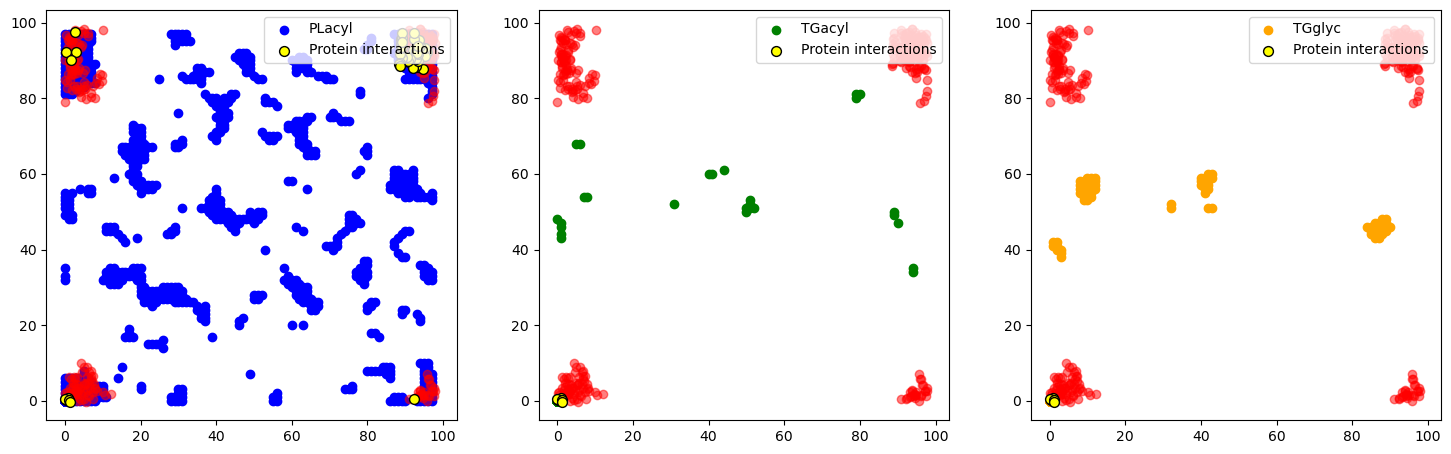

Processing Frame: 335


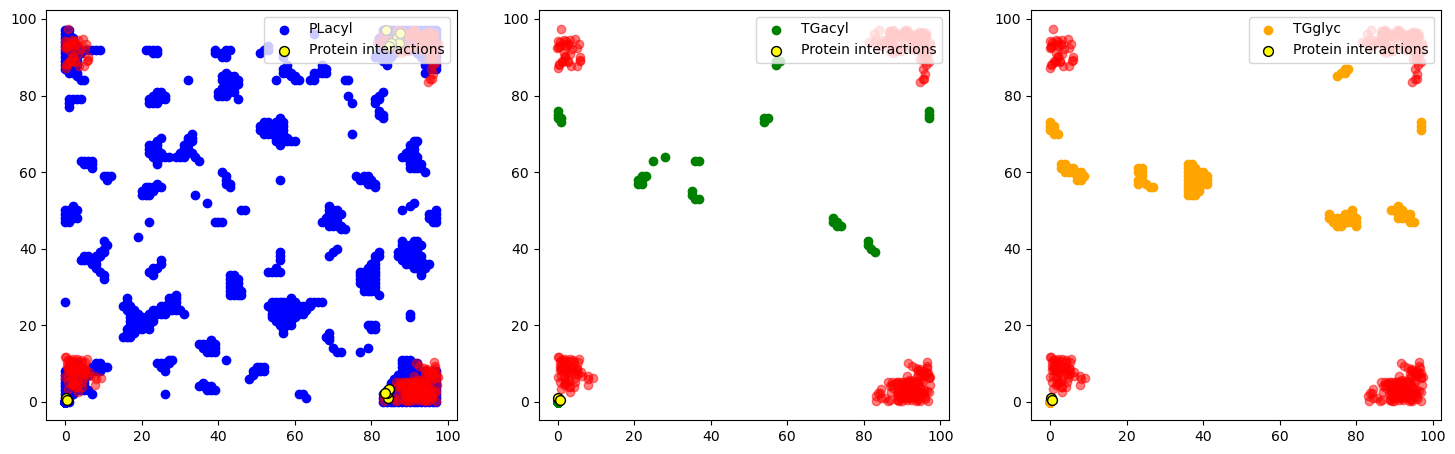

Processing Frame: 336


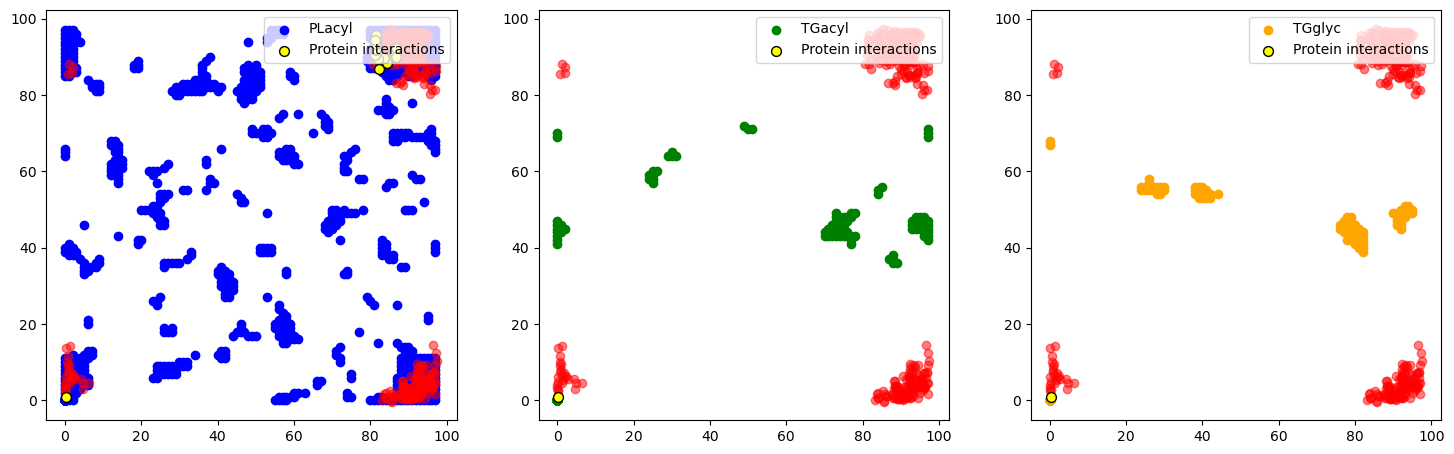

Processing Frame: 337


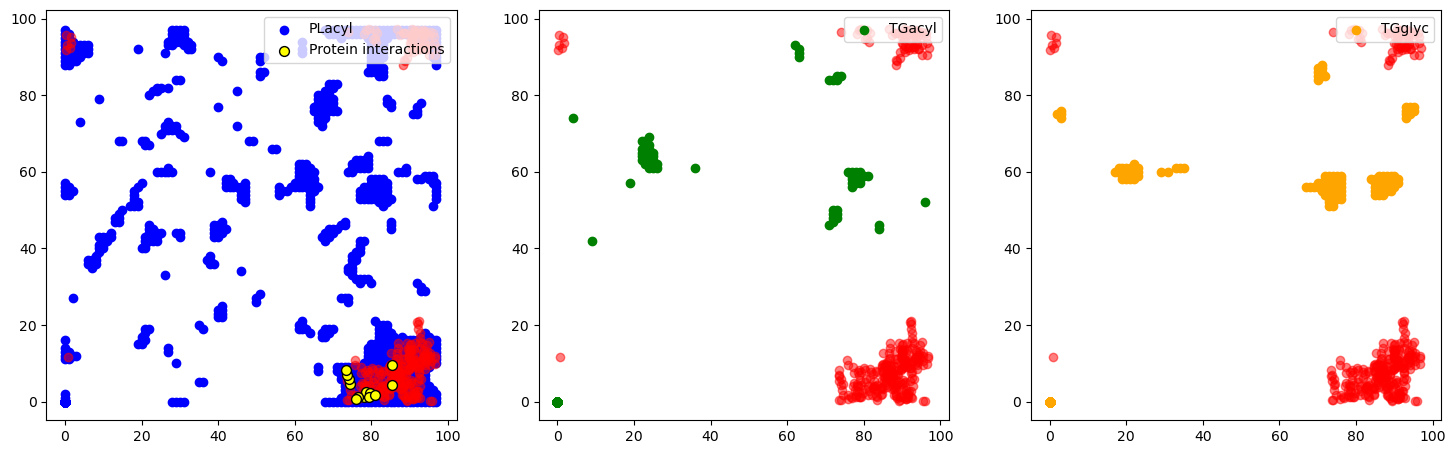

Processing Frame: 338


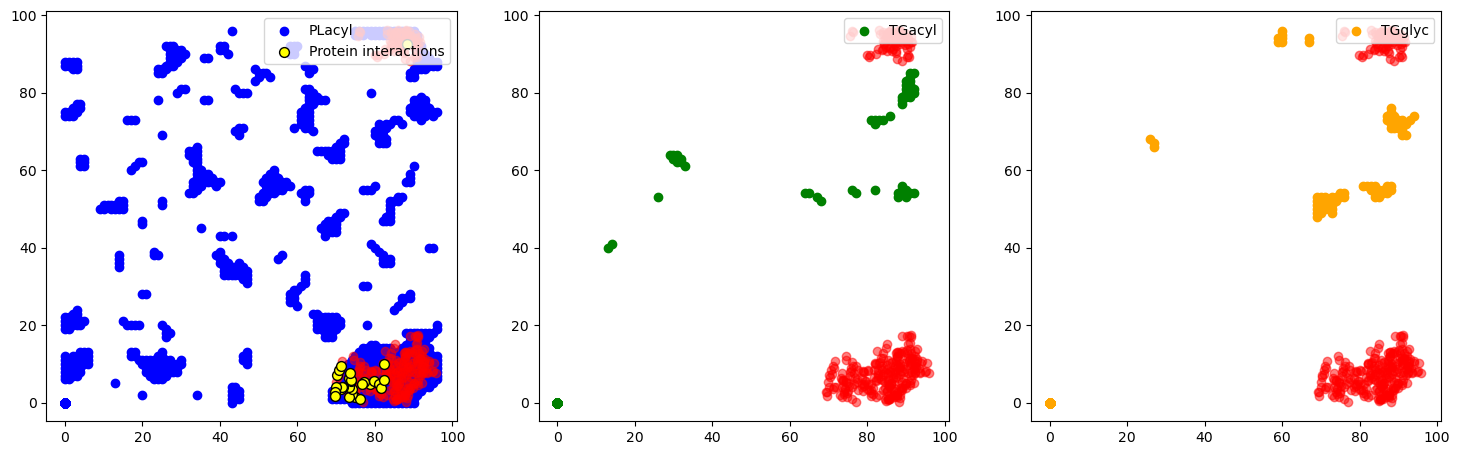

Processing Frame: 339


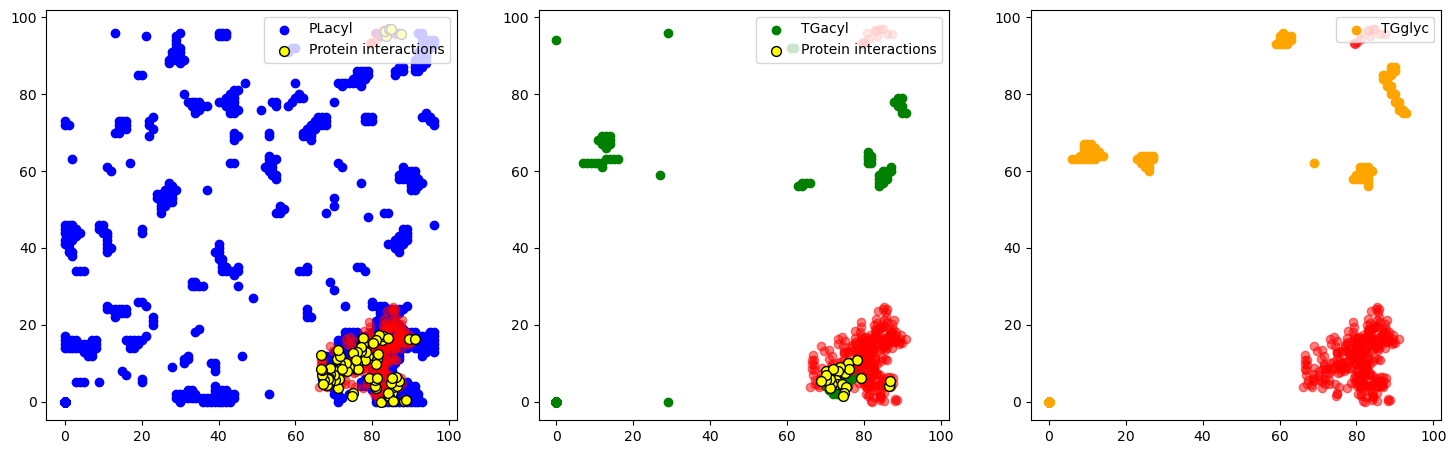

Processing Frame: 340


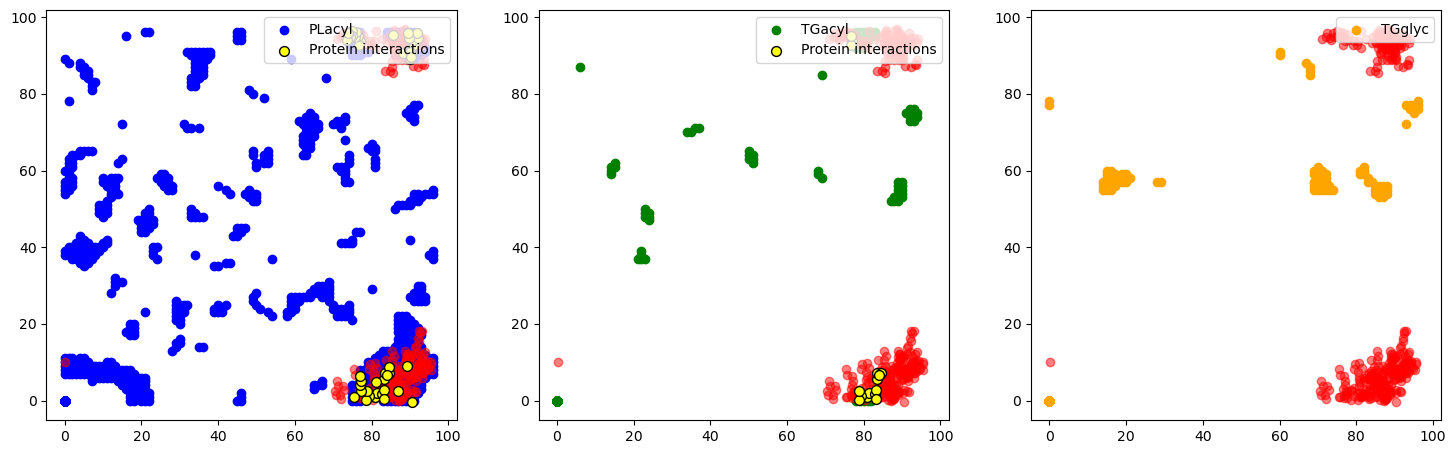

Processing Frame: 341


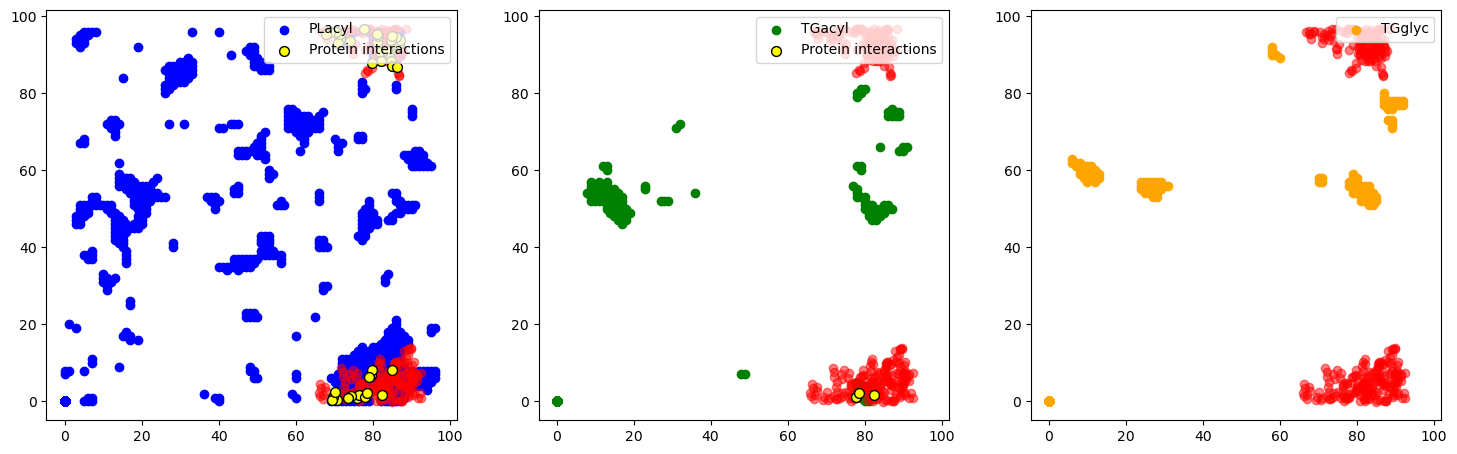

Processing Frame: 342


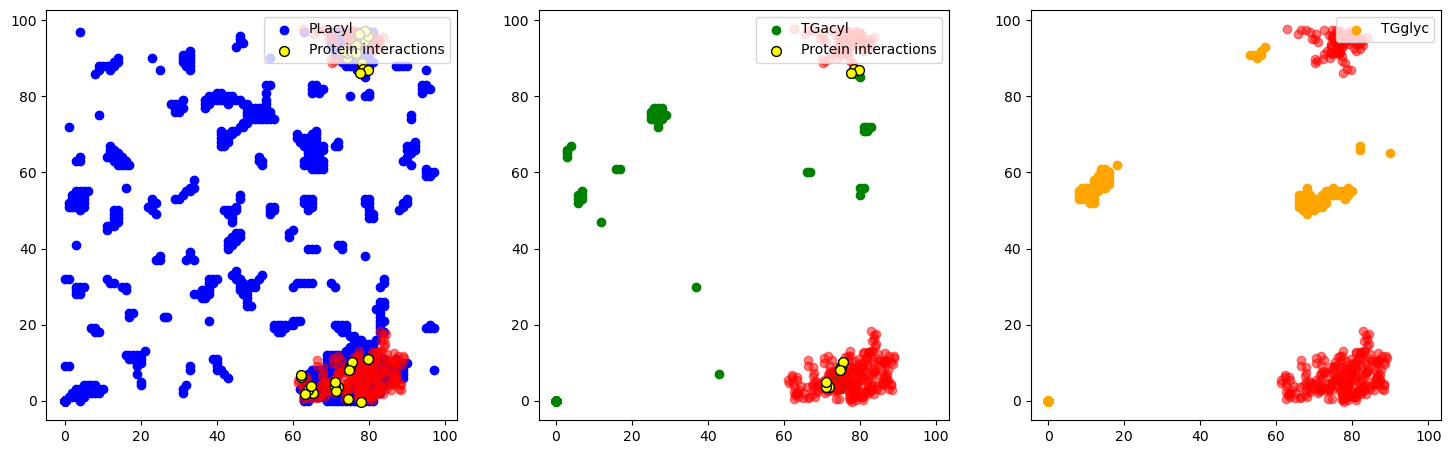

Processing Frame: 343


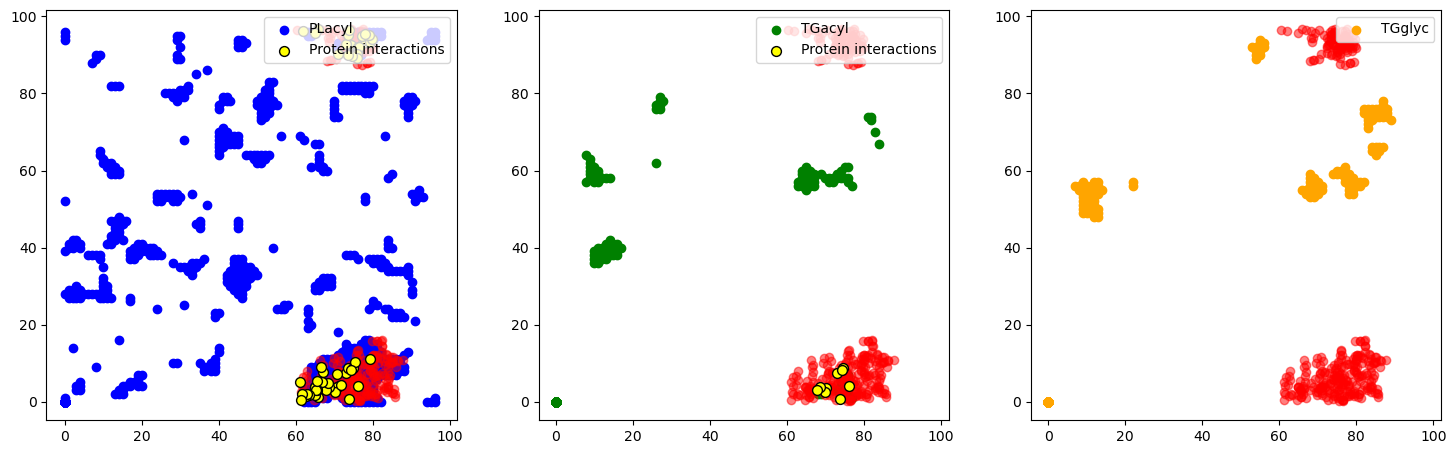

Processing Frame: 344


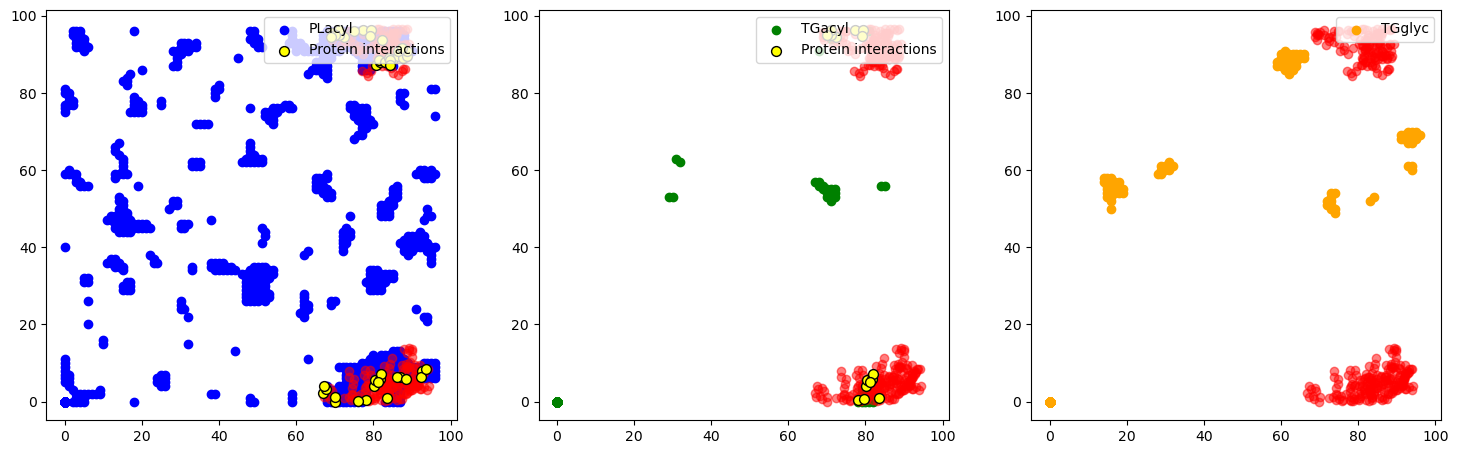

Processing Frame: 345


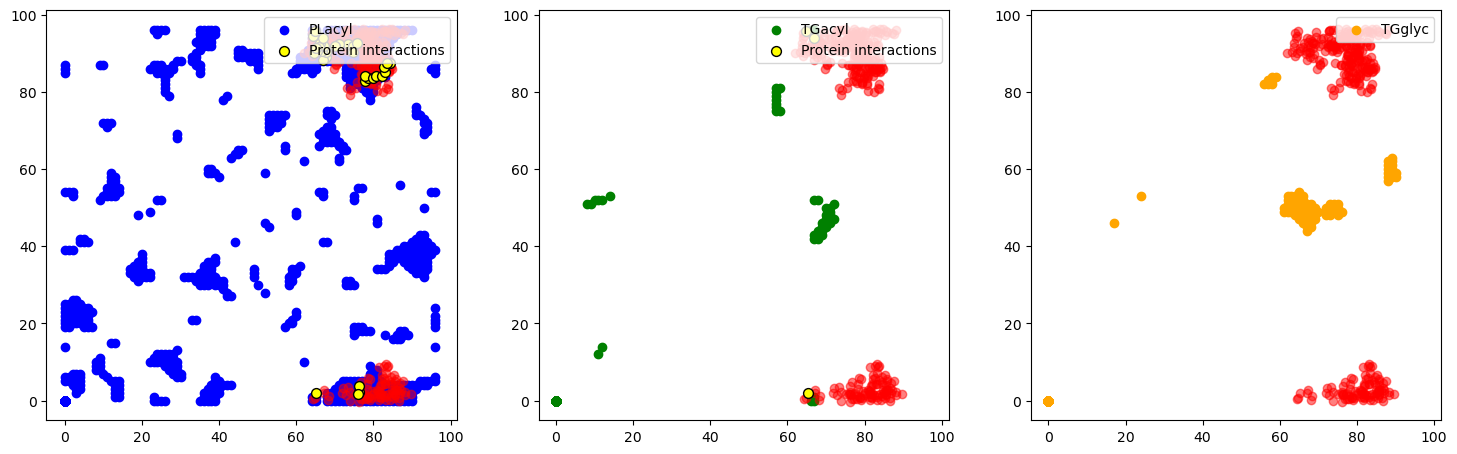

Processing Frame: 346


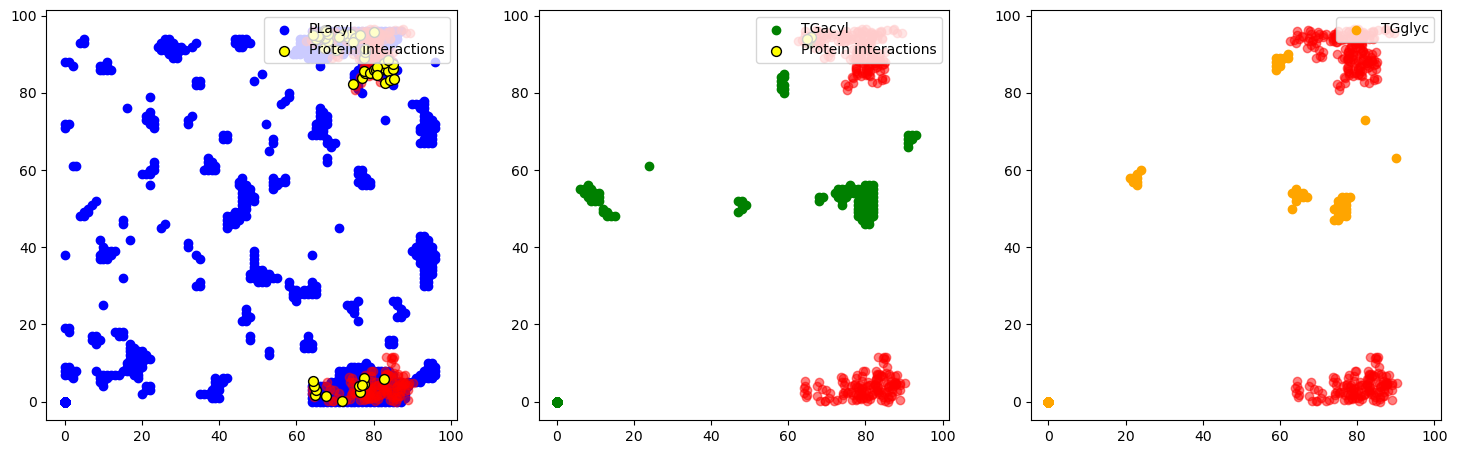

Processing Frame: 347


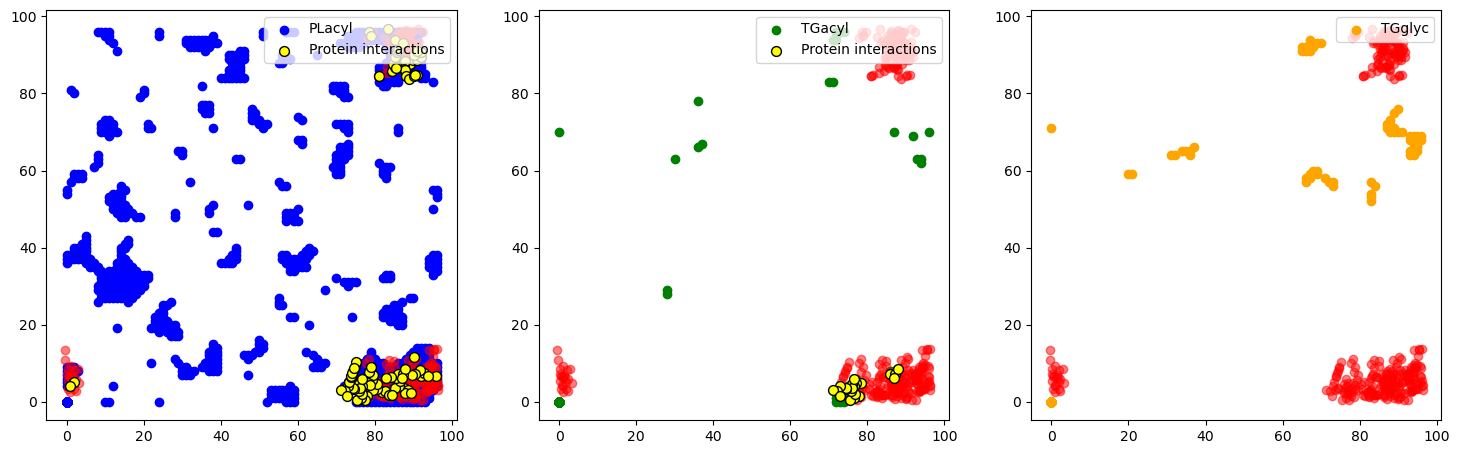

Processing Frame: 348


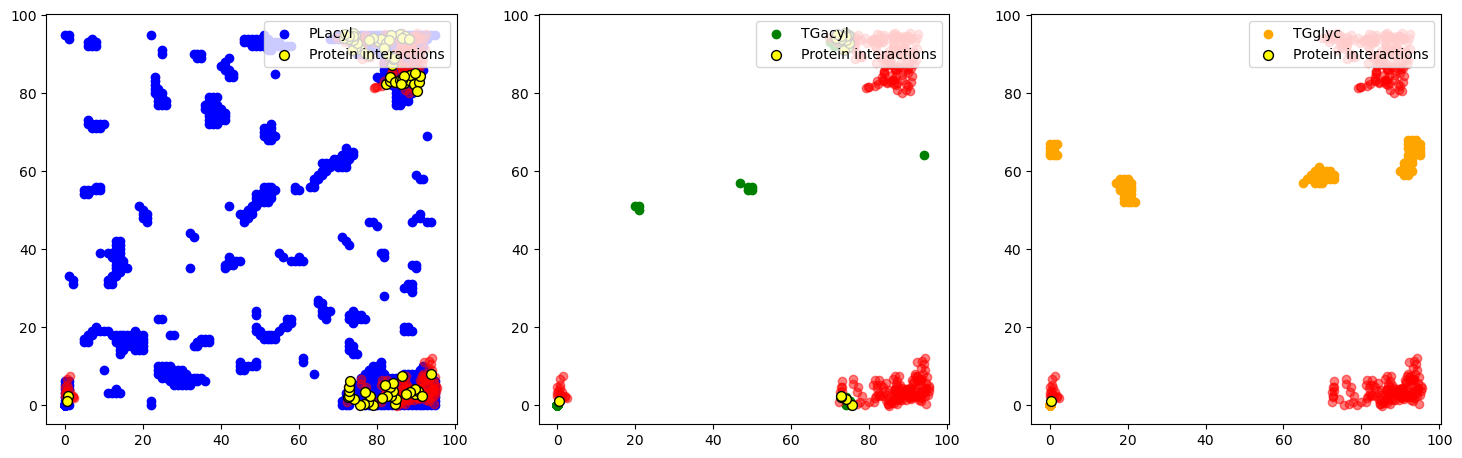

Processing Frame: 349


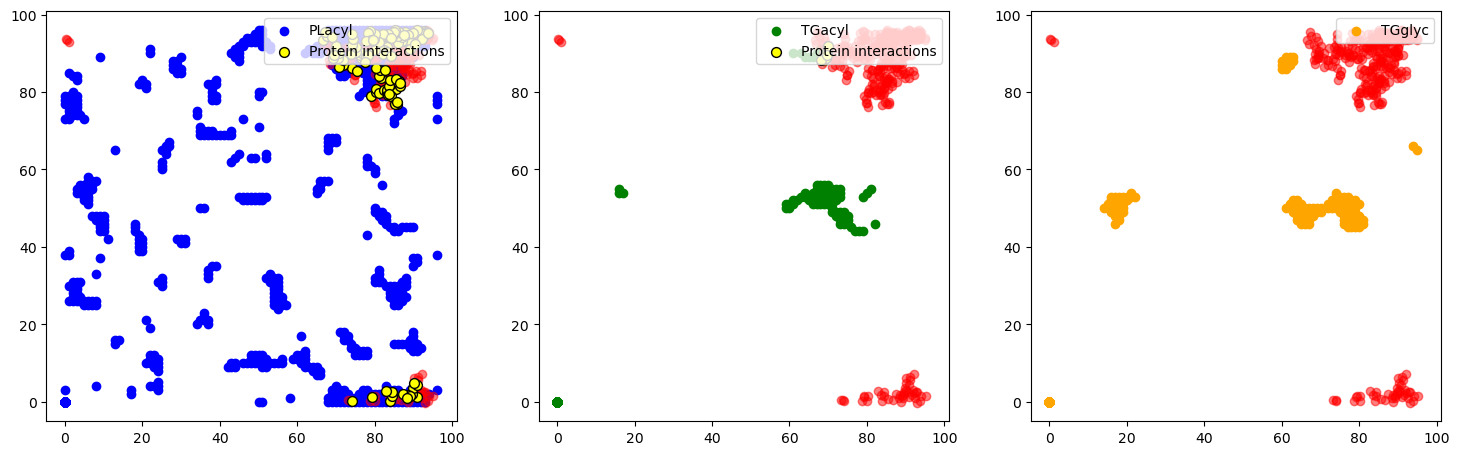

Processing Frame: 350


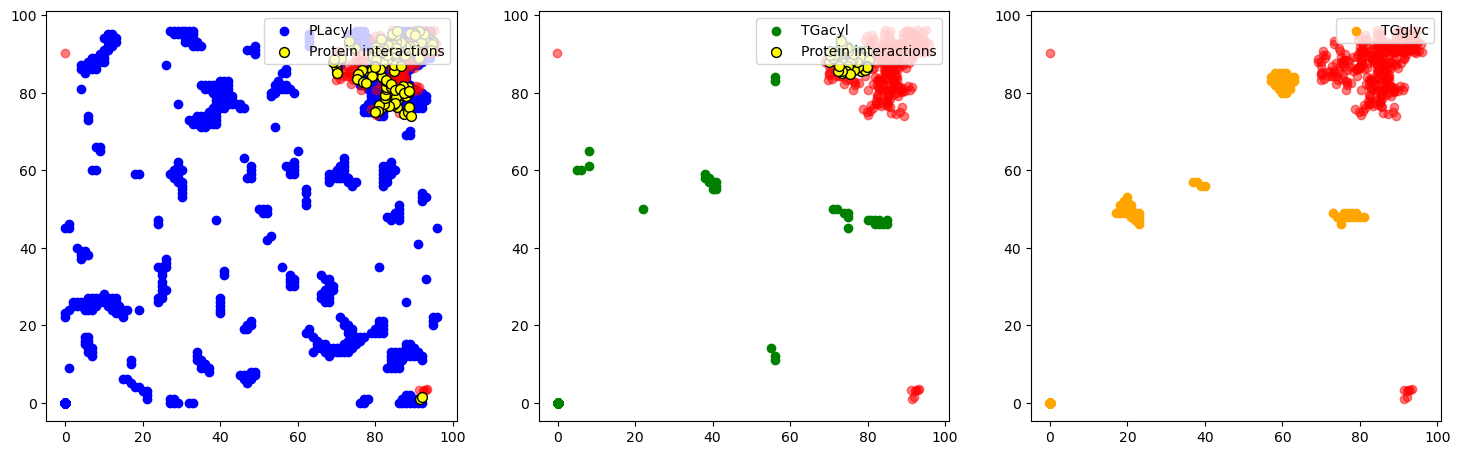

Processing Frame: 351


KeyboardInterrupt: 

<Figure size 1800x600 with 0 Axes>

In [17]:
def main():
    config = MDConfig(
        start_frame=319, 
        end_frame=999, 
        protein_atoms=626, 
        # This is where files are coming from
        directory_prefix='GRO/GRO/output_', 
        
        # These are folders we are creating
        plots_directory='3_TEST', 
        csv_directory='csv_TEST', 
        file_prefix='rep3_TEST'
    )

    check_and_create_directory(config.plots_directory)
    check_and_create_directory(config.csv_directory)

    all_atoms_defects_residues_map = {}

    for frame_idx in range(config.start_frame, config.end_frame + 1):
        print(f"Processing Frame: {frame_idx}")
        success = plot_molecules_from_gro(config, frame_idx, leaflet='bottom')
        if not success:
            print(f"No data for Frame: {frame_idx}, skipping.")
            continue

    if all_atoms_defects_residues_map:
        print("Data found, saving to CSV...")
        save_to_csv(all_atoms_defects_residues_map, config)
    else:
        print("No data collected, nothing to save.")

if __name__ == "__main__":
    main()